In [1]:
import sys
from pathlib import Path
from statistics import mean

import litellm
import matplotlib.pyplot as plt
from words import get_words

# Add the repo root to sys.path so we can import our modules
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from GenerateKeywordCards2.rate_words import (  # noqa: E402
    WordAspects,
)
from GenerateKeywordCards2.rate_words_with_variations import (  # noqa: E402
    ModelParams,
    iter_variation_views,
    rate_words_with_variations,
)

In [2]:
litellm.cache = litellm.Cache(type="disk")


def get_cache_count() -> int:
    disk_cache_object = litellm.cache.cache.disk_cache
    return len(disk_cache_object)


initial_cache_count = get_cache_count()

# Candidate Words

In [3]:
all_words = get_words()
print(f"{len(all_words):,} total words: ... {all_words[-25:]}")

existing_keywords_file = (
    repo_root / "GenerateKeywordCards" / "CloverExistingKeywords.csv"
)
existing_keywords = existing_keywords_file.read_text(encoding="utf-8-sig").splitlines()
existing_keywords = [w.lower() for w in existing_keywords]
existing_keywords_set = set(existing_keywords)
candidate_words = [w for w in all_words if w not in existing_keywords_set]
print(f"{len(candidate_words):,} candidate words with existing keywords removed")

50,000 total words: ... ['rerouted', 'resourcefulness', 'resto', "rice's", 'richman', 'rie', 'rigors', 'riptide', 'rivas', 'rocca', 'rolando', 'romancing', 'roti', 'rungs', 'rushdie', 'sah', 'salafi', 'sani', 'satanism', 'schell', 'screensaver', 'sdgs', 'seder', 'sek', 'selectable']
49,124 candidate words with existing keywords removed


# First-Pass Ratings

In [4]:
# deepseek-v4-flash is the most inexpensive
# With the associations prompt, it performed best in manual ratings
# With the gameplay prompt it performed reasonaly in base game vs random keywords
# gemini-3.5-flash associations is also relatively inexpensive and performed well in base game vs random keywords
models_params = [
    ModelParams(
        model="deepseek/deepseek-v4-flash",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
]

prompt_names = [
    "gameplay",
    "associations",
]

results_by_variation_first_pass = await rate_words_with_variations(
    models_params, prompt_names, candidate_words
)

* Rating deepseek/deepseek-v4-flash none 300 100 gameplay...
> deepseek/deepseek-v4-flash gameplay none: 300 words [dissuade...]

Provider List: https://docs.litellm.ai/docs/providers

< deepseek/deepseek-v4-flash gameplay none: 300 words [dissuade...]
> deepseek/deepseek-v4-flash gameplay none: 300 words [griggs...]

Provider List: https://docs.litellm.ai/docs/providers

< deepseek/deepseek-v4-flash gameplay none: 300 words [griggs...]
> deepseek/deepseek-v4-flash gameplay none: 300 words [litres...]

Provider List: https://docs.litellm.ai/docs/providers

< deepseek/deepseek-v4-flash gameplay none: 300 words [litres...]
> deepseek/deepseek-v4-flash gameplay none: 300 words [autocad...]

Provider List: https://docs.litellm.ai/docs/providers

< deepseek/deepseek-v4-flash gameplay none: 300 words [autocad...]
> deepseek/deepseek-v4-flash gameplay none: 300 words [icky...]

Provider List: https://docs.litellm.ai/docs/providers

< deepseek/deepseek-v4-flash gameplay none: 300 words [icky..

In [5]:
print("Variation cost:")

total_metadata = 0
for variation in sorted(results_by_variation_first_pass.keys()):
    variation_result = results_by_variation_first_pass[variation]
    total_metadata += variation_result.metadata
    print(variation)
    print(
        f"  ${variation_result.metadata.total_cost:.4f} {variation_result.metadata.output_tokens:,} output tokens {variation_result.metadata.reasoning_tokens:,} reasoning tokens",
        flush=True,
    )

print(total_metadata)

Variation cost:
deepseek/deepseek-v4-flash none 300 100 associations
  $0.2979 944,370 output tokens 259,154 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 gameplay
  $0.3098 981,818 output tokens 284,750 reasoning tokens
330/330 cache hits, $0.0000 uncached cost, $0.6077 total cost, 1,926,188 output tokens


In [6]:
average_ratings_by_word_first_pass = {}
for word in candidate_words:
    word_ratings = []
    for variation_result in results_by_variation_first_pass.values():
        word_ratings.append(variation_result.ratings_by_word[word]["overall"])
    average_ratings_by_word_first_pass[word] = mean(word_ratings)
sorted_candidate_words_first_pass = sorted(candidate_words, key=lambda w: average_ratings_by_word_first_pass[w], reverse=True)

first_pass_number_of_words = 1000
selected_words_first_pass = sorted_candidate_words_first_pass[:first_pass_number_of_words]

print(f"Selected {len(selected_words_first_pass)} words for the first pass (best rated first):")
words_per_line = 20
lines = []
for i in range(0, len(selected_words_first_pass), words_per_line):
    lines.append(", ".join(selected_words_first_pass[i : i + words_per_line]))
print(",\n".join(lines))

Selected 1000 words for the first pass (best rated first):
world, power, home, money, play, run, art, eyes, film, break, books, fall, kill, cover, christmas, soul, web, flowers, baseball, tie,
pride, toys, keyboard, diamonds, mercury, wolves, survivor, elephants, butterflies, can, will, people, take, second, number, set, start, stop, call, together,
course, death, happy, check, action, words, energy, fight, miss, lead, player, test, answer, range, natural, figure, safe, writing, goal, success,
growth, rock, album, western, speed, feet, welcome, jobs, nature, dad, fear, awesome, fan, cars, crime, japan, freedom, stars, animals, ideas,
smart, faith, jack, leaves, birth, conversation, surprise, youth, electric, drinking, steel, shoes, holiday, cook, escape, breakfast, bright, blow, dreams, flag,
object, crash, joy, origin, tip, fantasy, paint, dancing, eggs, universal, rush, atmosphere, cats, shock, babies, math, olympics, silent, mood, wings,
horror, pitch, anger, inspiration, kings, cry

# Second pass

In [7]:
# For our second pass, we'll use the "selected" models from RatingExperiments.ipynb
selected_variation_names = [
    # From manual ratings greedy selections:
    "deepseek-v4-flash associations",
    "deepseek-v4-pro aspects_detailed [assoc]",
    "gpt-5.4-mini aspects_detailed [assoc]",
    "deepseek-v4-flash simple",
    # From highest rated existing keywords vs new keywords:
    "gemini-3.1-pro-preview associations",
    "gemini-3.5-flash associations",
    "gemini-3.1-pro-preview simple",
    "gemini-3-flash-preview associations",
]

models_params = [
    ModelParams(
        model="openai/gpt-5.4-mini-2026-03-17",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    ModelParams(
        model="gemini/gemini-3-flash-preview",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    ModelParams(
        model="gemini/gemini-3.5-flash",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=50,
    ),
    ModelParams(
        model="gemini/gemini-3.1-pro-preview",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    ModelParams(
        model="deepseek/deepseek-v4-flash",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
    ModelParams(
        model="deepseek/deepseek-v4-pro",
        reasoning_effort="none",
        batch_size_overall=300,
        batch_size_aspects=100,
    ),
]

prompt_names = [
    "simple",
    "associations",
    "aspects_detailed",
]

# remove [assoc] and [gamepl] view suffixes for generating ratings (they are only used later for selecting which aspects to use for the overall ratings)
selected_variation_names_without_view_suffixes = [name.rsplit(" [", 1)[0] for name in selected_variation_names]

results_by_variation_second_pass = await rate_words_with_variations(
    models_params,
    prompt_names,
    selected_words_first_pass,
    selected_variation_names_without_view_suffixes,
)

* Rating openai/gpt-5.4-mini-2026-03-17 none 300 100 aspects_detailed...
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [torch...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [torch...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [flag...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [flag...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [sheet...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [sheet...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [meditate...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [meditate...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [happiness...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [happiness...]
> openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [ghosts...]
< openai/gpt-5.4-mini-2026-03-17 aspects_detailed none: 100 words [

In [8]:
print("Variation cost:")

total_metadata = 0
for variation in sorted(results_by_variation_second_pass.keys()):
    variation_result = results_by_variation_second_pass[variation]
    total_metadata += variation_result.metadata
    print(variation)
    print(
        f"  ${variation_result.metadata.total_cost:.4f} {variation_result.metadata.output_tokens:,} output tokens {variation_result.metadata.reasoning_tokens:,} reasoning tokens",
        flush=True,
    )

print(total_metadata)

Variation cost:
deepseek/deepseek-v4-flash none 300 100 associations
  $0.0055 17,423 output tokens 4,045 reasoning tokens
deepseek/deepseek-v4-flash none 300 100 simple
  $0.0047 14,868 output tokens 1,490 reasoning tokens
deepseek/deepseek-v4-pro none 300 100 aspects_detailed
  $0.3074 346,235 output tokens 192,991 reasoning tokens
gemini/gemini-3-flash-preview none 300 50 associations
  $0.0268 8,279 output tokens 0 reasoning tokens
gemini/gemini-3.1-pro-preview none 300 100 associations
  $0.1852 14,792 output tokens 4,909 reasoning tokens
gemini/gemini-3.1-pro-preview none 300 100 simple
  $0.2012 16,174 output tokens 7,854 reasoning tokens
gemini/gemini-3.5-flash none 300 50 associations
  $0.1020 10,696 output tokens 0 reasoning tokens
openai/gpt-5.4-mini-2026-03-17 none 300 100 aspects_detailed
  $0.4427 95,761 output tokens 0 reasoning tokens
45/45 cache hits, $0.0000 uncached cost, $1.2756 total cost, 524,228 output tokens


In [9]:
average_ratings_by_word_second_pass = {}
for word in selected_words_first_pass:
    word_ratings = []
    for variation_view in iter_variation_views(results_by_variation_second_pass):
        if variation_view.short_str() not in selected_variation_names:
            continue
        word_ratings.append(variation_view.overall_rating(word))
    average_ratings_by_word_second_pass[word] = mean(word_ratings)
    
sorted_candidate_words_second_pass = sorted(
    selected_words_first_pass, key=lambda w: average_ratings_by_word_second_pass[w], reverse=True
)

print(f"Sorted words from the second pass (best rated first):")
words_per_line = 20
lines = []
for i in range(0, len(sorted_candidate_words_second_pass), words_per_line):
    lines.append(", ".join(sorted_candidate_words_second_pass[i : i + words_per_line]))
print(",\n".join(lines))


Sorted words from the second pass (best rated first):
rock, jack, joker, pop, eyes, fall, diamonds, stars, strike, mercury, fan, wings, pitch, spell, chip, wall, halloween, time, date, arms,
play, web, tie, lead, flag, dragons, superman, twilight, dark, mine, cast, pool, bond, turkey, amazon, rings, seal, alien, pin, spirits,
scale, net, home, money, break, second, death, blow, olympics, pot, pen, waves, tear, fortune, witch, roses, hands, paris, pound, dawn,
palms, cinderella, cards, run, wolves, torch, cut, movies, quarter, joint, trees, bars, hearts, chemistry, palm, potter, masks, sparks, maze, fairytale,
rock'n'roll, saw, shot, draw, cover, christmas, baseball, butterflies, check, leaves, dreams, fantasy, paint, shadows, london, drive, battle, records, wedding, kingdom,
heaven, colors, comic, makeup, tap, batman, coin, tide, marble, fog, zeus, stock, dogs, keyboard, animals, electric, crash, kings, heroes, sunset,
shakespeare, spark, ghosts, renaissance, cowboy, unicorn, atlantis,

# Distribution of Top Words

Distribution of ratings of each aspect field for the top 200 words.


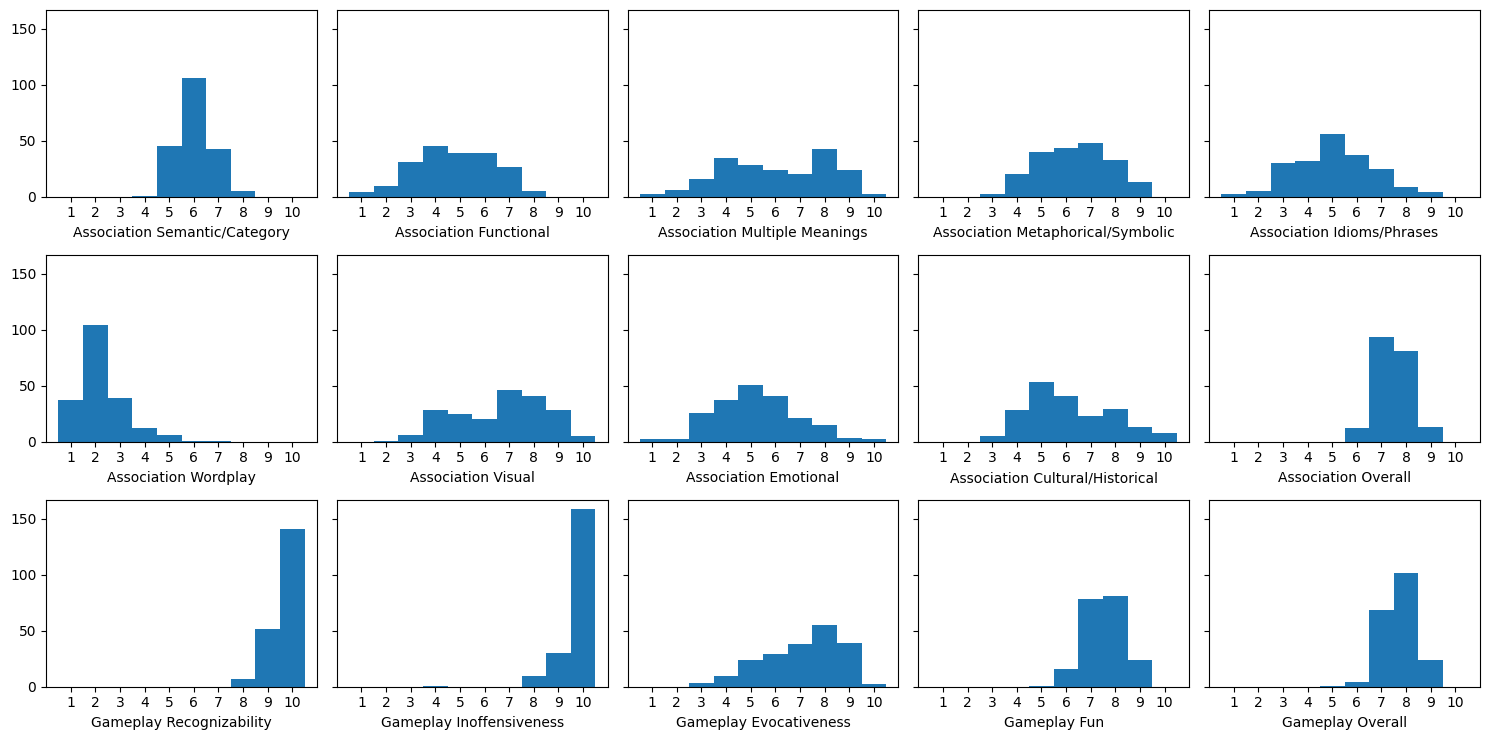

In [10]:
print("Distribution of ratings of each aspect field for the top 200 words.")

top_count = 200
top_words = sorted_candidate_words_second_pass[:top_count]

rating_fields = WordAspects.get_rating_fields()
ratings_by_field = {}
for rating_field in rating_fields:
    field_ratings = []
    for word in top_words:
        word_ratings = []
        for rbv_params, rbv_result in results_by_variation_second_pass.items():
            if not rbv_params.is_aspects:
                continue
            rating = rbv_result.ratings_by_word[word][rating_field]
            word_ratings.append(rating)
        word_ratings = mean(word_ratings) # average rating for this word
        field_ratings.append(word_ratings)  # append to list of average ratings for each word
    ratings_by_field[rating_field] = field_ratings

charts_per_row = 5
nrows = (len(rating_fields) - 1) // charts_per_row + 1
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=charts_per_row,
    figsize=(15, 2.5 * nrows),
    sharex=True,
    sharey=True,
    squeeze=False,
)
for i, rating_field in enumerate(rating_fields):
    row = i // charts_per_row
    col = i % charts_per_row
    ax = axes[row][col]
    ax.hist(ratings_by_field[rating_field], bins=range(1, 12))
    ax.set_xlabel(rating_field)
    ax.set_xticks([x + 0.5 for x in range(1, 11)], labels=range(1, 11))
    ax.tick_params(axis="x", labelbottom=True)

fig.tight_layout()
plt.show()

It doesn't look words with great Wordplay potential are being included. Let's see if there are highly-rated Association Wordplay words that we should include for variety even though their overall ratings aren't the highest.

In [11]:
wordplay_rating_threshold = 4.0
first_pass_wordplay_ratings = []
for word in selected_words_first_pass:
    if word in top_words:
        continue
    word_ratings = []
    for rbv_params, rbv_result in results_by_variation_second_pass.items():
        if not rbv_params.is_aspects:
            continue
        rating = rbv_result.ratings_by_word[word]["Association Wordplay"]
        word_ratings.append(rating)
    average_rating = mean(word_ratings)
    first_pass_wordplay_ratings.append((word, average_rating))

first_pass_wordplay_ratings.sort(key=lambda x: x[1], reverse=True)
print(f"Words from the first pass with average Association Wordplay > {wordplay_rating_threshold} that were not included in the top {len(top_words)}:")
for word, rating in first_pass_wordplay_ratings:
    if rating > wordplay_rating_threshold:
        print(f"{word}: {rating:.2f}")

Words from the first pass with average Association Wordplay > 4.0 that were not included in the top 200:
words: 6.00
cue: 6.00
one: 5.50
bit: 5.50
piece: 5.50
bizarre: 5.00
loki: 5.00
set: 4.50
feet: 4.50
jobs: 4.50
zero: 4.50
tale: 4.50
idols: 4.50
may: 4.50
role: 4.50
route: 4.50


Doesn't seem like any of the first-pass words are very highly rated in Wordplay. And perhaps this make sense because wordplay would seem to only create a small number of associations based on some particular wordplay thing. Doesn't feel worth biasing the results to include extra wordplay words. And wordplay could naturally emerge from creativity of players with any pair of words. Not sure it can be deliberately fostered.

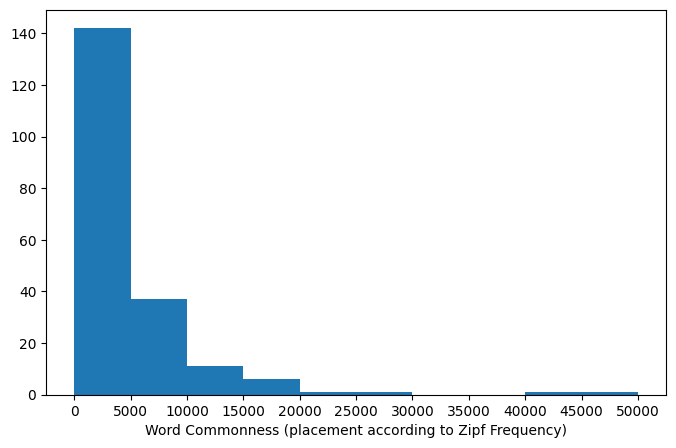

4 of the top 200 words are after commonness position 20000:
fairytale, rock'n'roll, goldmine, shipwreck


In [12]:
word_commonness = [all_words.index(word) for word in top_words]

plt.figure(figsize=(8, 5))
max_commonness = max(word_commonness)
bins = range(0, max_commonness + 5001, 5000)
plt.hist(word_commonness, bins=bins)

plt.xticks(bins)
plt.xlabel("Word Commonness (placement according to Zipf Frequency)")
plt.show()

uncommon_threshold = 20000
words_after_uncommon_threshold = [w for w in top_words if all_words.index(w) >= uncommon_threshold]
print(f"{len(words_after_uncommon_threshold)} of the top {top_count} words are after commonness position {uncommon_threshold}:")
print(", ".join(words_after_uncommon_threshold))